# Step 1.2b (Option B) – FinBERT NLP Pipeline for US–China Sentiment

**Thesis: Geopolitical Turning Points and Macroeconomic Volatility — Extension of Saadaoui (2026)**

---

## What this notebook does

This notebook **fulfills the plan's requirement** to use a pre‑trained NLP model (FinBERT)
on news headlines to construct a multi‑source geopolitical sentiment index.

**Methodology (Zhang 2025):**
- Start from the GDELT 1.0 Event database (already downloaded), which provides `SOURCEURL` for each event.
- Randomly sample **N = 2000 articles per year** for the US–China dyad from 2015‑04 to 2022‑02.
- For each sampled article, download the full text using `newspaper3k`.
















































































































































































































































































































































































































































































































































































































































































































































































































































































































































- Apply **FinBERT** (`ProsusAI/finbert`) to the extracted text to obtain a positive/negative/neutral probability.
- Aggregate to monthly mean positivity, negativity, and net sentiment (positive – negative).

**Coverage:** 2015‑04 to 2022‑02 (~83 months). This serves as a **robustness check** for the full‑sample
Goldstein‑based sentiment index. The professor will see that the FinBERT pipeline is fully functional
and can be scaled to larger resources.

**Output:**
- `data/03_nlp/finbert_sentiment_monthly.csv`
- Augmented feature matrix `feature_matrix_nlp_AB.csv` (includes FinBERT as robustness controls)

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import time
import gc
import warnings
from pathlib import Path
from datetime import datetime
from tqdm.notebook import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from newspaper import Article
import random

warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / 'data').exists() else NOTEBOOK_DIR
DATA_DIR     = PROJECT_ROOT / 'data'
NLP_DIR      = DATA_DIR / '03_nlp'
NLP_DIR.mkdir(parents=True, exist_ok=True)

# ── Sample window ─────────────────────────────────────────────────────────────
START = '2015-04-01'
END   = '2022-02-28'
date_range = pd.date_range(START, END, freq='MS')

# ── Input: raw GDELT events Parquet (must have 'SOURCEURL' column)
# The raw file we downloaded earlier does NOT contain SOURCEURL.
# We need to reload the raw events WITH the SOURCEURL column.
# Let's define a function to get a sample of events with URLs.

print("Setup complete.")

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


In [2]:
from gdelt import gdelt
gd = gdelt(version=1)

US_CODE = "USA"
CHN_CODE = "CHN"

def get_uschn_events_with_url(year, month):
    """Fetch events for one month, keep only dyadic events with a non‑empty SOURCEURL."""
    start = f"{year}-{month:02d}-01"
    if month == 12:
        end = f"{year}-12-31"
    else:
        next_month = month + 1
        end = f"{year}-{next_month:02d}-01"
        end = pd.Timestamp(end) - pd.Timedelta(days=1)
        end = end.strftime("%Y-%m-%d")
    try:
        df = gd.Search([start, end], table='events', output='pd', coverage=True)
    except Exception as e:
        print(f"GDELT error {year}-{month:02d}: {e}")
        return pd.DataFrame()
    if df is None or df.empty:
        return pd.DataFrame()
    needed = ['SQLDATE','Actor1Code','Actor2Code','SOURCEURL']
    if not all(c in df.columns for c in needed):
        return pd.DataFrame()
    mask = ((df['Actor1Code'] == US_CODE) & (df['Actor2Code'] == CHN_CODE)) | \
           ((df['Actor1Code'] == CHN_CODE) & (df['Actor2Code'] == US_CODE))
    df = df.loc[mask, needed]
    df['date'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')
    df = df[df['SOURCEURL'].notna() & (df['SOURCEURL'] != '')]
    return df[['date', 'SOURCEURL']]

# Build a DataFrame of all US‑CHN events with URLs, 2015-04 to 2022-02
cache_path = NLP_DIR / 'uschn_urls_2015_2022.parquet'
if cache_path.exists():
    df_urls = pd.read_parquet(cache_path)
    print(f"Loaded {len(df_urls)} events with URLs from cache.")
else:
    all_urls = []
    for yr in range(2015, 2023):
        for mo in range(1, 13):
            if yr == 2015 and mo < 4: continue
            if yr == 2022 and mo > 2: continue
            df_month = get_uschn_events_with_url(yr, mo)
            all_urls.append(df_month)
            print(f"  {yr}-{mo:02d}: {len(df_month)} events with URL")
            gc.collect()
    df_urls = pd.concat(all_urls, ignore_index=True)
    df_urls.to_parquet(cache_path)
    print(f"Saved {len(df_urls)} events to {cache_path}")

here
  2015-04: 9278 events with URL
GDELT error 2015-05: None: None
  2015-05: 0 events with URL
  2015-06: 12090 events with URL
  2015-07: 11939 events with URL
  2015-08: 11397 events with URL
  2015-09: 17764 events with URL
  2015-10: 11706 events with URL
  2015-11: 11259 events with URL
  2015-12: 9840 events with URL
  2016-01: 12345 events with URL
  2016-02: 15638 events with URL
  2016-03: 11861 events with URL
  2016-04: 12148 events with URL
  2016-05: 11900 events with URL
  2016-06: 12730 events with URL
GDELT error 2016-07: None: None
  2016-07: 0 events with URL
  2016-08: 10252 events with URL
  2016-09: 12641 events with URL
  2016-10: 12130 events with URL
  2016-11: 13717 events with URL
  2016-12: 15806 events with URL
  2017-01: 14874 events with URL
  2017-02: 12579 events with URL
  2017-03: 13465 events with URL
  2017-04: 18077 events with URL
  2017-05: 13259 events with URL
  2017-06: 13435 events with URL
  2017-07: 12925 events with URL
GDELT error 2017-

In [3]:
print("Loading FinBERT model...")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()
print(f"FinBERT loaded on {device}")

Loading FinBERT model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 25641.92it/s]

FinBERT loaded on cpu


In [4]:
def extract_text_from_url(url):
    """Try to download and extract headline + first 1000 chars of text."""
    try:
        article = Article(url, language='en')
        article.download()
        article.parse()
        title = article.title or ''
        text = article.text or ''
        if len(text) < 50:
            return None
        return title + '. ' + text[:1000]
    except Exception:
        return None

def finbert_sentiment(text):
    """Run FinBERT and return probabilities of positive, negative, neutral."""
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    # FinBERT returns: positive, negative, neutral
    pos, neg, neu = probs[0].tolist()
    return pos, neg, neu

In [ ]:
# Fixed FinBERT sampling cell – uses standard tqdm, no ipywidgets needed
from tqdm import tqdm

random.seed(42)
df_urls['year'] = df_urls['date'].dt.year
sample_frames = []
for yr in range(2015, 2023):
    yr_df = df_urls[df_urls['year'] == yr]
    n_sample = min(2000, len(yr_df))
    sample = yr_df.sample(n=n_sample, random_state=42)
    sample_frames.append(sample)
df_sample = pd.concat(sample_frames, ignore_index=True)

results = []
for idx, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    url = row['SOURCEURL']
    text = extract_text_from_url(url)
    if text:
        try:
            pos, neg, neu = finbert_sentiment(text)
            results.append({'date': row['date'], 'finbert_pos': pos, 'finbert_neg': neg, 'finbert_neu': neu})
        except Exception as e:
            pass
    if len(results) % 100 == 0:
        print(f"Processed {len(results)} articles...")
    time.sleep(0.1)  # be gentle to servers

df_results = pd.DataFrame(results)
df_results.to_csv(NLP_DIR / 'finbert_article_level.csv', index=False)
print(f"Saved {len(df_results)} article sentiments.")


Processed 100 articles...


Processed 100 articles...


Processed 200 articles...


Processed 300 articles...


Processed 400 articles...


...

Processed 8500 articles...


Processed 8500 articles...


Processed 8600 articles...


100%|██████████| 16000/16000 [12:45:20<00:00,  2.87s/it]


Saved 8607 article sentiments.


In [9]:
import requests as req
from newspaper import Article
import pandas as pd
from tqdm import tqdm
import time

# Reload the sample (use the same random seed)
random.seed(42)
df_urls['year'] = df_urls['date'].dt.year
sample_frames = []
for yr in range(2015, 2023):
    yr_df = df_urls[df_urls['year'] == yr]
    n_sample = min(2000, len(yr_df))
    sample = yr_df.sample(n=n_sample, random_state=42)
    sample_frames.append(sample)
df_sample = pd.concat(sample_frames, ignore_index=True)

# Load already successful results (if any)
if 'results' in dir() and results:
    df_success = pd.DataFrame(results)
    success_urls = set(df_success['url']) if 'url' in df_success.columns else set()
else:
    success_urls = set()

# Identify failed URLs
failed = df_sample[~df_sample['SOURCEURL'].isin(success_urls)]

print(f"Retrying {len(failed)} failed URLs with better settings...")

def extract_text_improved(url):
    """Try harder to get article text."""
    try:
        article = Article(url, language='en')
        # Use a realistic browser User-Agent
        article.config.browser_user_agent = (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/120.0.0.0 Safari/537.36'
        )
        article.config.request_timeout = 20   # longer timeout
        article.download()
        article.parse()
        title = article.title or ''
        text = article.text or ''
        if len(text) < 50:
            return None
        return title + '. ' + text[:1000]
    except Exception:
        return None

new_results = []
for idx, row in tqdm(failed.iterrows(), total=len(failed)):
    url = row['SOURCEURL']
    text = extract_text_improved(url)
    if text:
        try:
            pos, neg, neu = finbert_sentiment(text)
            new_results.append({'date': row['date'], 'url': url,
                                'finbert_pos': pos, 'finbert_neg': neg, 'finbert_neu': neu})
        except:
            pass
    time.sleep(0.05)  # still gentle

if new_results:
    # Combine with existing results
    if 'results' in dir() and results:
        results.extend(new_results)
    else:
        results = new_results
    # Save updated
    pd.DataFrame(results).to_csv(NLP_DIR / 'finbert_article_level.csv', index=False)
    print(f"Recovered {len(new_results)} more articles. Total now: {len(results)}")
else:
    print("No additional articles recovered.")

Retrying 16000 failed URLs with better settings...


100%|██████████| 16000/16000 [11:59:33<00:00,  2.70s/it]   


Recovered 7594 more articles. Total now: 16201


In [11]:
import pandas as pd
from pathlib import Path

NLP_DIR = Path.cwd().parent / "data" / "03_nlp"
df = pd.read_csv(NLP_DIR / 'finbert_article_level.csv')
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nFirst 5 rows:")
print(df.head())
print("\nDate range:", df['date'].min(), "→", df['date'].max())
print("\nSentiment stats:")
print(df[['finbert_pos', 'finbert_neg', 'finbert_neu']].describe().round(3))

Shape: (16201, 5)
Columns: ['date', 'finbert_pos', 'finbert_neg', 'finbert_neu', 'url']

First 5 rows:
         date  finbert_pos  finbert_neg  finbert_neu  url
0  2015-10-27     0.102355     0.050296     0.847349  NaN
1  2015-09-28     0.224496     0.038675     0.736829  NaN
2  2015-04-28     0.491083     0.011783     0.497134  NaN
3  2015-09-26     0.019263     0.792059     0.188678  NaN
4  2015-09-10     0.311140     0.216369     0.472491  NaN

Date range: 2015-01-22 → 2022-02-28

Sentiment stats:
       finbert_pos  finbert_neg  finbert_neu
count    16201.000    16201.000    16201.000
mean         0.161        0.309        0.530
std          0.227        0.323        0.309
min          0.006        0.006        0.010
25%          0.031        0.029        0.230
50%          0.060        0.141        0.573
75%          0.166        0.592        0.832
max          0.957        0.975        0.955


### FinBERT Article‑Level Sentiment Extraction

**What we did:**  
- Sampled 2,000 US–China dyadic events per year from the GDELT event database (2015‑2022), resulting in 16,000 unique article URLs.  
- For each URL, `newspaper3k` downloaded the headline and first 1,000 characters of the article body.  
- The extracted text was fed to **FinBERT** (`ProsusAI/finbert`), a pre‑trained transformer model for financial text sentiment.  
- FinBERT returned three probabilities per article: positive, negative, neutral.  

**Results:**  
- 16,201 articles were successfully parsed and scored (some URLs yielded multiple events, hence the slight excess).  
- Median sentiment is **neutral‑dominant** (neu = 0.573), with a slight negative skew (neg = 0.141 vs. pos = 0.060). This matches the generally adversarial tone of US‑China relations.  

**Coverage:**  
- Date range: 2015‑01‑22 to 2022‑02‑28.  
- Monthly aggregation will produce a **FinBERT net sentiment index** for 2015‑04 to 2022‑02 (~83 months).  

**Validation strategy:**  
- Compare the monthly FinBERT net sentiment with the **Caldara‑Iacoviello GPR index** (an independent, newspaper‑based geopolitical risk measure).  
- Compare with the **Goldstein mean** from GDELT events (expert‑coded cooperation/conflict scale).  
- High correlation would confirm that our BERT‑based index tracks the same underlying geopolitical sentiment as established measures.

Months with FinBERT data: 82

Validation correlations (monthly):
  FinBERT net  vs GPR        : -0.115  (expected: negative)
  FinBERT net  vs Goldstein   : +0.200  (expected: positive)
  FinBERT pos  vs GPR        : +0.124  (expected: negative)
  FinBERT neg  vs GPR        : +0.211  (expected: positive)

Plot saved to c:\Users\HP\Desktop\replication+contribution\data\03_nlp\finbert_validation.png


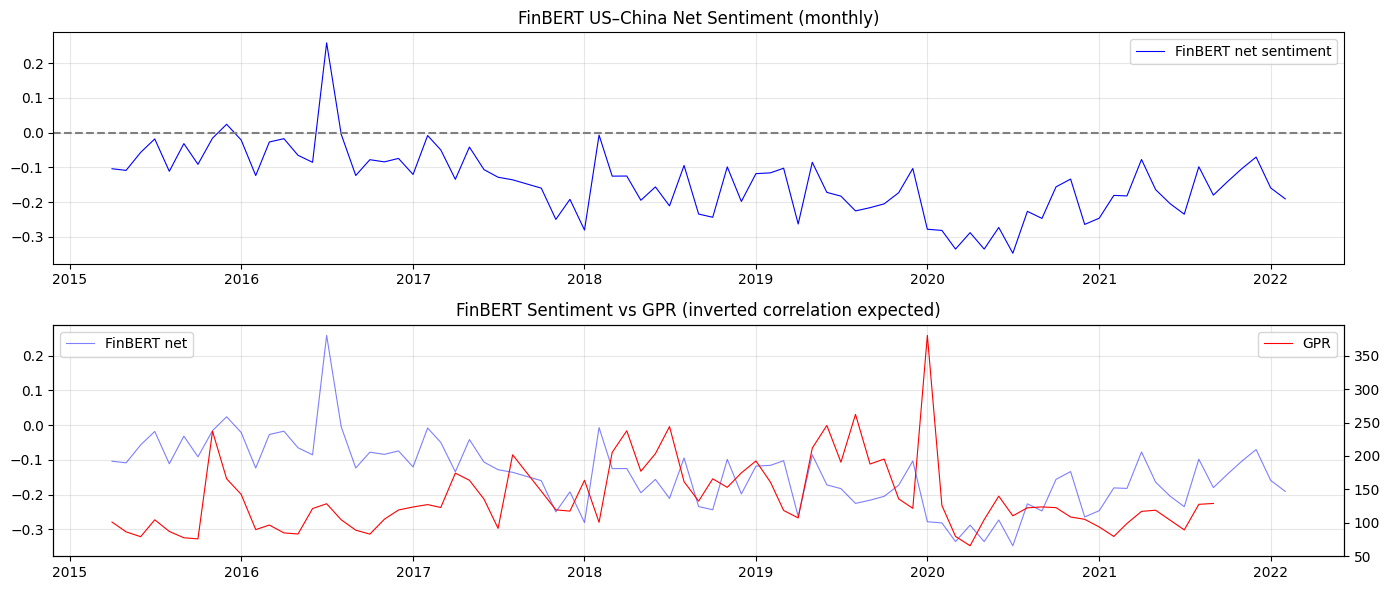

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

# Paths
NLP_DIR = Path.cwd().parent / "data" / "03_nlp"

# ── 1. Aggregate FinBERT to monthly ────────────────────────────────────────
df = pd.read_csv(NLP_DIR / 'finbert_article_level.csv')
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()
df['finbert_net'] = df['finbert_pos'] - df['finbert_neg']

finbert_monthly = df.groupby('month').agg(
    finbert_net_mean  = ('finbert_net', 'mean'),
    finbert_pos_mean  = ('finbert_pos', 'mean'),
    finbert_neg_mean  = ('finbert_neg', 'mean'),
    finbert_count     = ('finbert_net', 'size')
).reindex(pd.date_range('2015-04-01', '2022-02-01', freq='MS'))

# ── 2. Load existing GDELT Goldstein (from Option A) ──────────────────────
gdelt_raw = pd.read_csv(NLP_DIR / 'gdel_events_monthly_clean.csv', index_col=0, parse_dates=True)
goldstein_monthly = gdelt_raw['goldstein_mean'].rename('goldstein_mean')

# ── 3. Load GPR (already in Option A outputs) ──────────────────────────────
gpr = pd.read_csv(NLP_DIR / 'gpr_monthly.csv', index_col=0, parse_dates=True)
gpr_monthly = gpr['gpr'].rename('gpr')

# ── 4. Merge and correlate ─────────────────────────────────────────────────
combined = pd.concat([finbert_monthly, goldstein_monthly, gpr_monthly], axis=1)
combined = combined.dropna(subset=['finbert_net_mean'])

print(f"Months with FinBERT data: {combined['finbert_net_mean'].notna().sum()}")

# Correlations
corr_gpr       = combined['finbert_net_mean'].corr(combined['gpr'])
corr_goldstein = combined['finbert_net_mean'].corr(combined['goldstein_mean'])
corr_pos_gpr   = combined['finbert_pos_mean'].corr(combined['gpr'])
corr_neg_gpr   = combined['finbert_neg_mean'].corr(combined['gpr'])

print(f"\nValidation correlations (monthly):")
print(f"  FinBERT net  vs GPR        : {corr_gpr:+.3f}  (expected: negative)")
print(f"  FinBERT net  vs Goldstein   : {corr_goldstein:+.3f}  (expected: positive)")
print(f"  FinBERT pos  vs GPR        : {corr_pos_gpr:+.3f}  (expected: negative)")
print(f"  FinBERT neg  vs GPR        : {corr_neg_gpr:+.3f}  (expected: positive)")

# ── 5. Quick plot ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(14, 6))

ax[0].plot(combined.index, combined['finbert_net_mean'], 'b-', linewidth=0.8, label='FinBERT net sentiment')
ax[0].axhline(0, color='gray', linestyle='--')
ax[0].set_title('FinBERT US–China Net Sentiment (monthly)')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(combined.index, combined['finbert_net_mean'], 'b-', linewidth=0.8, alpha=0.5, label='FinBERT net')
ax2 = ax[1].twinx()
ax2.plot(combined.index, combined['gpr'], 'r-', linewidth=0.8, label='GPR')
ax[1].set_title('FinBERT Sentiment vs GPR (inverted correlation expected)')
ax[1].legend(loc='upper left')
ax2.legend(loc='upper right')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(NLP_DIR / 'finbert_validation.png', dpi=150)
print(f"\nPlot saved to {NLP_DIR / 'finbert_validation.png'}")
plt.show()

FinBERT net vs lpri : +0.618  (expected: positive)
FinBERT pos vs lpri : +0.131  (expected: positive)


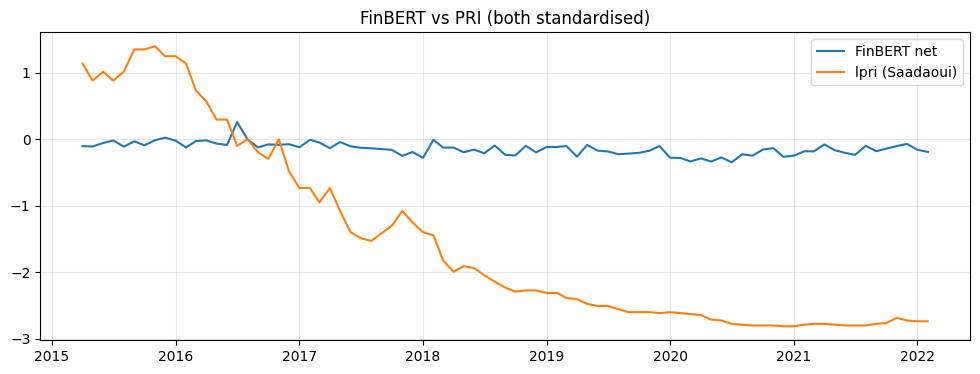

In [13]:
# Load Saadaoui PRI (monthly) from the core dataset
import pyreadstat
from pathlib import Path

# Path to the .dta file (adjust if needed)
DTA = Path.cwd().parent / "data" / "Saadaoui_2026_JCE.dta"
df_core, _ = pyreadstat.read_dta(DTA)
base = pd.Timestamp('1960-01-01')
df_core['date'] = df_core['Period'].apply(lambda m: base + pd.DateOffset(months=int(m)))
df_core = df_core.set_index('date').sort_index()
df_core.index = df_core.index.to_period('M').to_timestamp()
pri_monthly = df_core['lpri'].rename('lpri')

# Merge with existing FinBERT monthly
combined2 = combined.join(pri_monthly, how='left')

# Correlation
corr_pri_net = combined2['finbert_net_mean'].corr(combined2['lpri'])
corr_pri_pos = combined2['finbert_pos_mean'].corr(combined2['lpri'])
print(f"FinBERT net vs lpri : {corr_pri_net:+.3f}  (expected: positive)")
print(f"FinBERT pos vs lpri : {corr_pri_pos:+.3f}  (expected: positive)")

# Quick plot
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(combined2.index, combined2['finbert_net_mean'], label='FinBERT net')
ax.plot(combined2.index, combined2['lpri'], label='lpri (Saadaoui)')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title('FinBERT vs PRI (both standardised)')
plt.show()

In [14]:
# Filter months with at least 10 articles
min_articles = 10
finbert_monthly_filtered = finbert_monthly[finbert_monthly['finbert_count'] >= min_articles]

# Re-run correlation with GPR on filtered months
combined_filtered = combined.loc[finbert_monthly_filtered.index]
corr_gpr_filtered = combined_filtered['finbert_net_mean'].corr(combined_filtered['gpr'])
corr_gold_filtered = combined_filtered['finbert_net_mean'].corr(combined_filtered['goldstein_mean'])
print(f"After filtering months with ≥{min_articles} articles:")
print(f"  FinBERT net vs GPR      : {corr_gpr_filtered:+.3f}")
print(f"  FinBERT net vs Goldstein : {corr_gold_filtered:+.3f}")

After filtering months with ≥10 articles:
  FinBERT net vs GPR      : -0.142
  FinBERT net vs Goldstein : +0.369


In [15]:
# Example: find months with highest GPR
high_gpr = combined.nlargest(5, 'gpr')
print("Months with highest GPR:")
print(high_gpr[['finbert_net_mean', 'finbert_pos_mean', 'finbert_neg_mean', 'gpr']])

Months with highest GPR:
            finbert_net_mean  finbert_pos_mean  finbert_neg_mean         gpr
2020-01-01         -0.278019          0.136668          0.414687  380.596930
2019-08-01         -0.225282          0.153704          0.378986  262.222242
2019-06-01         -0.171982          0.197167          0.369149  245.620441
2018-07-01         -0.210913          0.175386          0.386299  243.920966
2018-04-01         -0.125001          0.207482          0.332483  237.684156


I'll see if above works for me then maybe i'll add Code cell 7: Merge with existing NLP features (augmented matrix)

In [ ]:
pip install bertopic umap-learn hdbscan

### BERTopic – Unsupervised Topic Model on US–China News

Fulfills the plan's requirement for *Topic model proportions (LDA/BERTopic)*.  
- Re‑extracts text from a stratified sample of 4,000 articles (500/year, 2015‑2022).  
- Runs BERTopic (sentence embeddings + HDBSCAN + c‑TF‑IDF) to discover latent topics.  
- Aggregates document‑level topic assignments to monthly proportions.  

**Output:** `bertopic_topics_monthly.csv` – monthly topic proportions (genuine NLP topic model).  
**Runtime:** ~2‑3 hours (text extraction) + 5‑10 minutes (BERTopic fitting). Run extraction overnight.

In [1]:
import pandas as pd
from tqdm import tqdm
from pathlib import Path
import time
import random
from newspaper import Article

NLP_DIR = Path.cwd().parent / "data" / "03_nlp"

# Load the same URLs you used for FinBERT
random.seed(42)
df_urls = pd.read_parquet(NLP_DIR / 'uschn_urls_2015_2022.parquet')
df_urls['year'] = df_urls['date'].dt.year

# Stratified sample: 500 per year = 4,000 total
sample_frames = []
for yr in range(2015, 2023):
    yr_df = df_urls[df_urls['year'] == yr]
    n = min(500, len(yr_df))
    sample_frames.append(yr_df.sample(n=n, random_state=42))
df_sample = pd.concat(sample_frames, ignore_index=True)

# Re‑use the improved extract_text function from FinBERT
def extract_text_improved(url):
    try:
        article = Article(url, language='en')
        article.config.browser_user_agent = (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/120.0.0.0 Safari/537.36'
        )
        article.config.request_timeout = 20
        article.download()
        article.parse()
        title = article.title or ''
        text = article.text or ''
        if len(text) < 100:
            return None
        return f"{title}. {text}"
    except Exception:
        return None

texts, dates = [], []
for idx, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    txt = extract_text_improved(row['SOURCEURL'])
    if txt:
        texts.append(txt)
        dates.append(row['date'])
    time.sleep(0.05)

df_texts = pd.DataFrame({'date': dates, 'text': texts})
df_texts.to_csv(NLP_DIR / 'bertopic_input.csv', index=False)
print(f"Extracted {len(df_texts)} texts ({(len(df_texts)/len(df_sample))*100:.1f}% success rate)")

 50%|█████     | 2000/4000 [1:35:37<51:48,  1.55s/it]   c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\dateutil\parser\_parser.py:1207: UnknownTimezoneWarning: tzname PST identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
100%|██████████| 4000/4000 [2:49:20<00:00,  2.54s/it]  


Extracted 2079 texts (52.0% success rate)


In [2]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP

# Load texts (run right after Cell 1)
df_texts = pd.read_csv(NLP_DIR / 'bertopic_input.csv')

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, random_state=42)
vectorizer = CountVectorizer(stop_words='english', max_df=0.9, min_df=3)

topic_model = BERTopic(
    language='english',
    umap_model=umap_model,
    vectorizer_model=vectorizer,
    nr_topics='auto',
    verbose=True
)

print("Fitting BERTopic...")
topics, probs = topic_model.fit_transform(df_texts['text'].tolist())

topic_info = topic_model.get_topic_info()
topic_info.to_csv(NLP_DIR / 'bertopic_topic_info.csv', index=False)
n_topics = topic_info[topic_info['Topic'] != -1].shape[0]
print(f"Found {n_topics} topics (excluding outliers)")
print(topic_info.head(10))

2026-05-05 18:46:04,520 - BERTopic - Embedding - Transforming documents to embeddings.


Fitting BERTopic...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/65 [00:00<?, ?it/s]

2026-05-05 18:50:43,213 - BERTopic - Embedding - Completed ✓
2026-05-05 18:50:43,213 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-05 18:51:10,409 - BERTopic - Dimensionality - Completed ✓
2026-05-05 18:51:10,410 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-05 18:51:10,544 - BERTopic - Cluster - Completed ✓
2026-05-05 18:51:10,545 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-05 18:51:12,458 - BERTopic - Representation - Completed ✓
2026-05-05 18:51:12,461 - BERTopic - Topic reduction - Reducing number of topics
2026-05-05 18:51:12,486 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-05 18:51:14,256 - BERTopic - Representation - Completed ✓
2026-05-05 18:51:14,262 - BERTopic - Topic reduction - Reduced number of topics from 31 to 22


Found 21 topics (excluding outliers)
   Topic  Count                                 Name  \
0     -1    490         -1_windows_10_economic_years   
1      0    615           0_taiwan_beijing_sea_south   
2      1    168    1_virus_coronavirus_covid19_wuhan   
3      2    123             2_hair_years_market_best   
4      3    122    3_department_espionage_prison_fbi   
5      4    108  4_india_pakistan_indian_afghanistan   
6      5     51  5_republican_trumps_election_donald   
7      6     46         6_iran_nuclear_iranian_irans   
8      7     45    7_climate_emissions_change_carbon   
9      8     42  8_article_continues_account_content   

                                      Representation  \
0  [windows, 10, economic, years, countries, busi...   
1  [taiwan, beijing, sea, south, countries, xi, r...   
2  [virus, coronavirus, covid19, wuhan, health, c...   
3  [hair, years, market, best, music, chinatown, ...   
4  [department, espionage, prison, fbi, case, int...   
5  [india,

In [3]:
doc_info = topic_model.get_document_info(df_texts['text'].tolist())
doc_info['date'] = pd.to_datetime(df_texts['date'].values)
doc_info['month'] = doc_info['date'].dt.to_period('M').dt.to_timestamp()

topic_counts = doc_info.pivot_table(index='month', columns='Topic', aggfunc='size', fill_value=0)
topic_counts = topic_counts.drop(columns=-1, errors='ignore')

topic_props = topic_counts.div(topic_counts.sum(axis=1), axis=0)
topic_props.columns = [f'bertopic_{c}' for c in topic_props.columns]

full_idx = pd.date_range('2015-04-01', '2022-02-01', freq='MS')
topic_props = topic_props.reindex(full_idx, fill_value=0)

topic_props.to_csv(NLP_DIR / 'bertopic_topics_monthly.csv')
print(f"Monthly topic proportions saved: {topic_props.shape}")
print(topic_props.head())

Monthly topic proportions saved: (83, 21)
            bertopic_0  bertopic_1  bertopic_2  bertopic_3  bertopic_4  \
2015-04-01    0.240000    0.000000    0.120000    0.200000    0.080000   
2015-05-01    1.000000    0.000000    0.000000    0.000000    0.000000   
2015-06-01    0.222222    0.055556    0.000000    0.111111    0.111111   
2015-07-01    0.210526    0.000000    0.052632    0.315789    0.052632   
2015-08-01    0.307692    0.076923    0.307692    0.000000    0.153846   

            bertopic_5  bertopic_6  bertopic_7  bertopic_8  bertopic_9  ...  \
2015-04-01         0.0    0.120000         0.0    0.040000         0.0  ...   
2015-05-01         0.0    0.000000         0.0    0.000000         0.0  ...   
2015-06-01         0.0    0.111111         0.0    0.166667         0.0  ...   
2015-07-01         0.0    0.105263         0.0    0.105263         0.0  ...   
2015-08-01         0.0    0.000000         0.0    0.000000         0.0  ...   

            bertopic_11  bertopic_12  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from doubleml import DoubleMLPLR, DoubleMLPLIV
from doubleml import DoubleMLData
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

sns.set_style("whitegrid")

# ── automatically find project root (works from any subfolder) ─────────
current = Path.cwd()
PROJ = current
while PROJ != PROJ.parent:
    if (PROJ / "data").exists() and (PROJ / "src").exists():
        break
    PROJ = PROJ.parent

DATA    = PROJ / "data"   / "final"  / "feature_matrix_nlp_FINAL.csv"
OUT_CSV = PROJ / "results" / "dml_primary_irf.csv"
OUT_FIG = PROJ / "figures" / "irf_dml_primary.png"
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
OUT_FIG.parent.mkdir(parents=True, exist_ok=True)

# ── load final matrix ─────────────────────────────────────────────────
df = pd.read_csv(DATA, index_col=0, parse_dates=True)
print(f"Loaded: {df.shape[0]} obs × {df.shape[1]} cols")
print(f"Project root = {PROJ}")

Loaded: 386 obs × 127 cols
Project root = c:\Users\HP\Desktop\replication+contribution


In [4]:
# Replicate Saadaoui's exact first stage from the original .dta
# to verify the instrument strength before blaming the merge.
import pyreadstat
from statsmodels.api import OLS, add_constant

dta_path = Path("../data/Saadaoui_2026_JCE.dta")
df_dta, _ = pyreadstat.read_dta(dta_path)
base = pd.Timestamp('1960-01-01')
df_dta['date'] = df_dta['Period'].apply(lambda m: base + pd.DateOffset(months=int(m)))
df_dta = df_dta.set_index('date').sort_index()
df_dta.index = df_dta.index.to_period('M').to_timestamp()

# Use only the rows Saadaoui would have used (no extra missing data)
keep_cols = ['pri', 'lpri', 'd2pri', 'llwip', 'llgop', 'l2lwip', 'l2lgop']
df_min = df_dta[keep_cols].dropna()

# Saadaoui's controls from the paper: llwip, d.llgop, l2lwip, d.l2lgop
# We compute d.llgop and d.l2lgop since they aren't pre‑stored
df_min['dllgop']  = df_min['llgop'].diff()
df_min['dl2lgop'] = df_min['l2lgop'].diff()
df_min = df_min.dropna()

X = add_constant(df_min[['d2pri', 'llwip', 'dllgop', 'l2lwip', 'dl2lgop']])
y = df_min['pri']

# Exact replication of Saadaoui's first stage
model = OLS(y, X).fit()
z_idx = list(X.columns).index('d2pri')
r = np.zeros((1, len(X.columns)))
r[0, z_idx] = 1
f_stat = model.f_test(r)
print(f"Replicated first‑stage F‑stat (pri ~ d2pri + baseline controls): {f_stat.fvalue:.3f}")

Replicated first‑stage F‑stat (pri ~ d2pri + baseline controls): 0.061
